Comparing Algebra2/Trigonometry Regents scores between 2015,2016 and 2017 in Manhattan

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
schools_data = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [8]:
schools_data.head(20)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na
5,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2015,9,67.4,3,33.3,6,66.7,0,0,na,na
6,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2016,15,72.6,2,13.3,13,86.7,5,33.3,na,na
7,01M140,P.S. 140 Nathan Straus,K-8,Living Environment,2017,9,64.4,5,55.6,4,44.4,1,11.1,na,na
8,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2015,49,78.4,1,2,48,98,23,46.9,48,98
9,01M184,P.S. 184m Shuang Wen,K-8,Common Core Algebra,2016,51,79,9,17.6,42,82.4,33,64.7,40,78.4


In [9]:
schools_data.tail(20)

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212311,84X706,Harriet Tubman Charter School,K-8,Common Core Algebra,2017,15,82.6,0,0,15,100,12,80,15,100
212312,84X706,Harriet Tubman Charter School,K-8,Common Core Algebra,2017,7,s,s,s,s,s,s,s,na,na
212313,84X706,Harriet Tubman Charter School,K-8,Common Core Algebra,2017,1,s,s,s,s,s,s,s,na,na
212314,84X706,Harriet Tubman Charter School,K-8,Integrated Algebra,2015,13,s,s,s,s,s,s,s,na,na
212315,84X706,Harriet Tubman Charter School,K-8,Integrated Algebra,2015,3,s,s,s,s,s,s,s,na,na
212316,84X706,Harriet Tubman Charter School,K-8,Living Environment,2015,1,s,s,s,s,s,s,s,na,na
212317,84X706,Harriet Tubman Charter School,K-8,U.S. History and Government,2017,3,s,s,s,s,s,s,s,na,na
212318,84X717,Icahn Charter School,K-8,Common Core Algebra,2015,5,s,s,s,s,s,s,s,na,na
212319,84X717,Icahn Charter School,K-8,Common Core Algebra,2015,2,s,s,s,s,s,s,s,na,na
212320,84X717,Icahn Charter School,K-8,Common Core Algebra,2016,8,87.9,0,0,8,100,7,87.5,8,100


In [16]:
schools_data.shape

(212331, 15)

In [17]:
schools_data.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [64]:
algebra2_trigonometry_data = schools_data[schools_data['Regents Exam'] == 'Algebra2/Trigonometry']
algebra2_trigonometry_data.tail()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212218,84X704,KIPP Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2015,19,67.5,6,31.6,13,68.4,2,10.5,2,10.5
212219,84X704,KIPP Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2015,35,72.1,10,28.6,25,71.4,9,25.7,9,25.7
212220,84X704,KIPP Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2016,14,68.4,6,42.9,8,57.1,1,7.1,1,7.1
212221,84X704,KIPP Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2016,50,72.9,9,18,41,82,17,34,17,34
212222,84X704,KIPP Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2017,6,52.5,6,100,0,0,0,0,0,0


In [32]:
schools_with_M_dbn = algebra2_trigonometry_data[schools_data['School DBN'].str.contains('M', na=False)]
schools_with_M_dbn.tail(20)

/tmp/ipykernel_615/1342198700.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  schools_with_M_dbn = algebra2_trigonometry_data[schools_data['School DBN'].str.contains('M', na=False)]


,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
209943,84M522,Broome Street Academy Charter School,High school,Algebra2/Trigonometry,2015,1,s,s,s,s,s,s,s,na,na
209944,84M522,Broome Street Academy Charter School,High school,Algebra2/Trigonometry,2016,18,47.8,16,88.9,2,11.1,0,0,0,0
209945,84M522,Broome Street Academy Charter School,High school,Algebra2/Trigonometry,2016,11,s,s,s,s,s,s,s,na,na
209946,84M522,Broome Street Academy Charter School,High school,Algebra2/Trigonometry,2016,3,s,s,s,s,s,s,s,na,na
210072,84M707,John V. Lindsay Wildcat Academy Charter School,High school,Algebra2/Trigonometry,2016,1,s,s,s,s,s,s,s,na,na
210150,84M709,Harlem Village Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2015,11,s,s,s,s,s,s,s,na,na
210151,84M709,Harlem Village Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2015,1,s,s,s,s,s,s,s,na,na
210152,84M709,Harlem Village Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2016,45,50.5,36,80,9,20,3,6.7,3,6.7
210153,84M709,Harlem Village Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2016,6,42.2,5,83.3,1,16.7,1,16.7,1,16.7
210154,84M709,Harlem Village Academy Charter School,K-12 all grades,Algebra2/Trigonometry,2017,16,s,s,s,s,s,s,s,na,na


In [33]:
schools_with_M_dbn = schools_with_M_dbn[['School DBN', 'Regents Exam', 'Year', 'Total Tested', 'Mean Score']]
schools_with_M_dbn.head(30)

,School DBN,Regents Exam,Year,Total Tested,Mean Score
18,01M292,Algebra2/Trigonometry,2015,5,s
19,01M292,Algebra2/Trigonometry,2016,5,s
59,01M448,Algebra2/Trigonometry,2015,45,62.2
60,01M448,Algebra2/Trigonometry,2016,55,59.8
61,01M448,Algebra2/Trigonometry,2017,11,58.6
128,01M509,Algebra2/Trigonometry,2015,19,74.2
129,01M509,Algebra2/Trigonometry,2016,15,50.9
159,01M515,Algebra2/Trigonometry,2015,60,85.4
160,01M515,Algebra2/Trigonometry,2016,75,77.7
161,01M515,Algebra2/Trigonometry,2017,18,78.1


In [39]:
schools_with_M_dbn['Mean Score'] = pd.to_numeric(schools_with_M_dbn["Mean Score"], errors='coerce')
schools_with_M_dbn = schools_with_M_dbn[(schools_with_M_dbn['Mean Score'] !=0) & schools_with_M_dbn['Mean Score'].notna()]
schools_with_M_dbn.head(30)

,School DBN,Regents Exam,Year,Total Tested,Mean Score
59,01M448,Algebra2/Trigonometry,2015,45,62.2
60,01M448,Algebra2/Trigonometry,2016,55,59.8
61,01M448,Algebra2/Trigonometry,2017,11,58.6
128,01M509,Algebra2/Trigonometry,2015,19,74.2
129,01M509,Algebra2/Trigonometry,2016,15,50.9
159,01M515,Algebra2/Trigonometry,2015,60,85.4
160,01M515,Algebra2/Trigonometry,2016,75,77.7
161,01M515,Algebra2/Trigonometry,2017,18,78.1
192,01M539,Algebra2/Trigonometry,2015,180,80.7
193,01M539,Algebra2/Trigonometry,2016,175,80.6


In [35]:
unique_years = schools_with_M_dbn['Year'].unique()
unique_years

array([2015, 2016, 2017])

In [40]:
schools_with_M_dbn_2015 = schools_with_M_dbn[schools_with_M_dbn['Year'] == 2015]
print("DataFrame filtered for year 2015:")
schools_with_M_dbn_2015.head()

DataFrame filtered for year 2015:


,School DBN,Regents Exam,Year,Total Tested,Mean Score
59,01M448,Algebra2/Trigonometry,2015,45,62.2
128,01M509,Algebra2/Trigonometry,2015,19,74.2
159,01M515,Algebra2/Trigonometry,2015,60,85.4
192,01M539,Algebra2/Trigonometry,2015,180,80.7
281,02M047,Algebra2/Trigonometry,2015,14,53.0


In [51]:
schools_with_M_dbn_2016 = schools_with_M_dbn[schools_with_M_dbn['Year'] == 2016]
print("DataFrame filtered for year 2016:")
schools_with_M_dbn_2016.head()

DataFrame filtered for year 2016:


,School DBN,Regents Exam,Year,Total Tested,Mean Score
60,01M448,Algebra2/Trigonometry,2016,55,59.8
129,01M509,Algebra2/Trigonometry,2016,15,50.9
160,01M515,Algebra2/Trigonometry,2016,75,77.7
193,01M539,Algebra2/Trigonometry,2016,175,80.6
282,02M047,Algebra2/Trigonometry,2016,14,34.6


In [50]:
schools_with_M_dbn_2017 = schools_with_M_dbn[schools_with_M_dbn['Year'] == 2017]
print("DataFrame filtered for year 2017:")
schools_with_M_dbn_2017.head()

DataFrame filtered for year 2017:


,School DBN,Regents Exam,Year,Total Tested,Mean Score
61,01M448,Algebra2/Trigonometry,2017,11,58.6
161,01M515,Algebra2/Trigonometry,2017,18,78.1
283,02M047,Algebra2/Trigonometry,2017,8,38.4
336,02M135,Algebra2/Trigonometry,2017,7,40.1
747,02M374,Algebra2/Trigonometry,2017,10,51.1


In [45]:
average_mean_score_2015 = schools_with_M_dbn_2015['Mean Score'].mean()
print(f"The average Mean Score for schools with 'M' in their DBN in 2015 is :{average_mean_score_2015:.2f}")

The average Mean Score for schools with 'M' in their DBN in 2015 is :60.97


In [46]:
average_mean_score_2016 = schools_with_M_dbn_2016['Mean Score'].mean()
print(f"The average Mean Score for schools with 'M' in their DBN in 2016 is :{average_mean_score_2016:.2f}")

The average Mean Score for schools with 'M' in their DBN in 2016 is :57.50


In [47]:
average_mean_score_2017 = schools_with_M_dbn_2017['Mean Score'].mean()
print(f"The average Mean Score for schools with 'M' in their DBN in 2017 is :{average_mean_score_2017:.2f}")

The average Mean Score for schools with 'M' in their DBN in 2017 is :56.26


/tmp/ipykernel_615/725978559.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=years, y=average_mean_scores, palette='viridis')


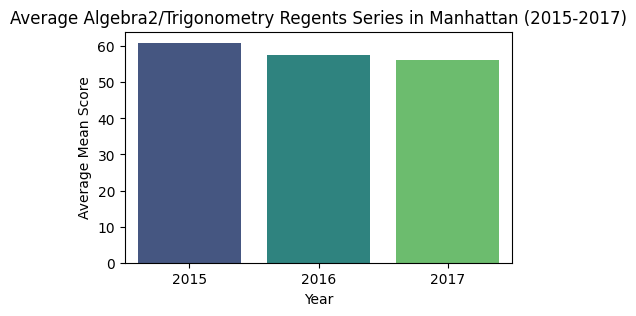

In [54]:
years = unique_years
average_mean_scores = [average_mean_score_2015, average_mean_score_2016, average_mean_score_2017]
plt.figure(figsize=(5,3))
sns.barplot(x=years, y=average_mean_scores, palette='viridis')
plt.title('Average Algebra2/Trigonometry Regents Series in Manhattan (2015-2017)')
plt.xlabel('Year')
plt.ylabel('Average Mean Score')
plt.show()

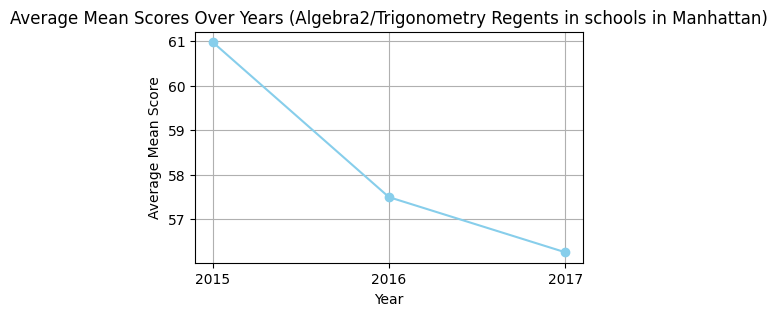

In [63]:
years = [2015, 2016, 2017]
average_scores = [average_mean_score_2015, average_mean_score_2016, average_mean_score_2017]
plt.figure(figsize=(5,3))
plt.plot(years, average_scores, marker='o', linestyle='-', color='skyblue')
plt.title('Average Mean Scores Over Years (Algebra2/Trigonometry Regents in schools in Manhattan)')
plt.xlabel('Year')
plt.ylabel('Average Mean Score')
plt.xticks(years)
plt.grid(True)
plt.show()

Based on the visualizations, I can conclude that the Average Mean Scores of Algebra2/Trgonometry in Manhattan decreased over years.